In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec

In [2]:
vis_epoch_lims=(-1.0, 2.0)
mot_epoch_lims=(-1.0, 1.5)
vis_plot_lims=(-0.25, 1.85)
mot_plot_lims=(-0.7, 1.2)

In [3]:
# Set global matplotlib parameters
plt.rcParams.update({
    'font.size': 14,
    'axes.spines.right': False,
    'axes.spines.top': False,
    'xtick.major.size': 6,
    'xtick.major.width': 1.2,
    'ytick.major.size': 6,
    'ytick.major.width': 1.2,
    'legend.frameon': False,
    'legend.handletextpad': 0.1,
    'svg.fonttype': 'none',
    'text.usetex': False
})

# Define color palettes
colors0 = sns.color_palette("magma", n_colors=6)
colors1 = sns.color_palette("mako_r", n_colors=10)
pastel = sns.color_palette("Pastel1", n_colors=6)
adapt1 = sns.color_palette("Set1", n_colors=9)
adapt2 = sns.color_palette("Accent", n_colors=8)
colors4 = sns.color_palette("magma_r", n_colors=4)
colors5 = sns.color_palette("mako_r", n_colors=4)

colors2 = [pastel[0], pastel[3], adapt2[5]]
colors3 = [pastel[1], pastel[2], colors5[2]]
colors_implicit = [pastel[0], adapt2[5], pastel[3]]  # Baseline, Washout, Adaptation
colors_explicit = [pastel[1], colors5[2], pastel[2]]  # Baseline, Washout, Adaptation
colorbl = [adapt1[4], colors1[2]]

# Define plot limits and proportional widths
plot_lims = {'vis': vis_plot_lims, 'mot': mot_plot_lims}
durations = {k: plot_lims[k][1] - plot_lims[k][0] for k in ['vis', 'mot']}
total_width = durations['vis'] + durations['mot']
width_ratios = [durations['vis'] / total_width, durations['mot'] / total_width]

In [4]:
def plot_var_results(var_name, disp_name):
    vis_df = pd.read_csv(f"output/overall_vis_burst_rate_{var_name}.csv")
    mot_df = pd.read_csv(f"output/overall_mot_burst_rate_{var_name}.csv")
    try:
        vis_stats = pd.read_csv(f"output/overall_vis_{var_name}_win.csv")
    except:
        vis_stats = pd.DataFrame({
            'pc': [],
            'quartile': [],
            'start': []
        })
    try:
        mot_stats = pd.read_csv(f"output/overall_mot_{var_name}_win.csv")
    except:
        mot_stats = pd.DataFrame({
            'pc': [],
            'quartile': [],
            'start': []
        })
    
    group_colors = {"Implicit": colorbl[0], "Explicit": colorbl[1]}
    plot_lims = {'vis': vis_plot_lims, 'mot': mot_plot_lims}
    
    if 'dur' in var_name or 'rt' in var_name:
        vis_df['estimate']=vis_df['estimate']*1000
        mot_df['estimate']=mot_df['estimate']*1000
        vis_df['SE']=vis_df['SE']*1000
        mot_df['SE']=mot_df['SE']*1000
        
    vis_df = vis_df[np.isfinite(vis_df["SE"])]
    mot_df = mot_df[np.isfinite(mot_df["SE"])]

    y_all = pd.concat([vis_df["estimate"], mot_df["estimate"]])
    y_min, y_max = y_all.min(), y_all.max()
    y_span = y_max - y_min
    y_offset_unit = 0.2 * y_span
    y_exp_marker = y_max + y_offset_unit
    y_imp_marker = y_exp_marker + y_offset_unit

    fig = plt.figure(figsize=(10, 4))
    gs = fig.add_gridspec(1, 2, width_ratios=width_ratios)
    group_list = ["Implicit", "Explicit"]
    common_ylim = (y_min - y_offset_unit, y_imp_marker + y_offset_unit)

    for idx, (subset, limits, title, stats_df, full_df) in zip(
        range(2),
        [(vis_df, plot_lims['vis'], "vis", vis_stats, vis_df),
         (mot_df, plot_lims['mot'], "mot", mot_stats, mot_df)]
    ):
        ax = fig.add_subplot(gs[idx])

        stats_df=stats_df[(stats_df['start']>limits[0])]
        
        for group in group_list:
            df_group = subset[(subset['group'] == group) & (np.isfinite(subset['SE']))].copy()
            if df_group.empty:
                continue

            time = df_group['time'].astype(float).values
            est = df_group['estimate'].astype(float).values
            se = df_group['SE'].astype(float).values

            ax.plot(time, est, label=group, color=group_colors[group], linewidth=2)
            ax.fill_between(time, est - se, est + se, alpha=0.2, color=group_colors[group])

        interaction_idxs=np.zeros(time.shape)

        for index, stats_row in stats_df.iterrows():
            start=stats_row['start']
            end=stats_row['end']
            chi_sq=stats_row['chi_sq']
            dof=stats_row['df']
            p_val=stats_row['p_val']
            if stats_row['factor']=='group:mean_burst_count':
                exp_onesamp_z=stats_row['explicit_onesamp_z']
                exp_onesamp_p=stats_row['explicit_onesamp_p']
                imp_onesamp_z=stats_row['implicit_onesamp_z']
                imp_onesamp_p=stats_row['implicit_onesamp_p']
                explicit_implicit_z=stats_row['explicit_implicit_z']
                explicit_implicit_p=stats_row['explicit_implicit_p']
                
                print(f'{title}: group:mean_burst_count {start}-{end}s, ChiSq({dof})={chi_sq}, p = {p_val}')
                print(f'         explicit: z = {exp_onesamp_z}, p = {exp_onesamp_p}')
                print(f'         implicit: z = {imp_onesamp_z}, p = {imp_onesamp_p}')
                print(f'         explicit - implicit: z = {explicit_implicit_z}, p = {explicit_implicit_p}')
                
                t_idx=np.where((time>=start) & (time<end))[0]
                if exp_onesamp_p<0.05:
                    ax.scatter(time[t_idx], [y_exp_marker] * len(t_idx),
                               color=group_colors['Explicit'], marker="*", s=80, zorder=10)
                if imp_onesamp_p<0.05:
                    ax.scatter(time[t_idx], [y_imp_marker] * len(t_idx),
                               color=group_colors['Implicit'], marker="*", s=80, zorder=10)
                interaction_idxs[t_idx]=True
                
        for index, stats_row in stats_df.iterrows():
            start=stats_row['start']
            end=stats_row['end']
            chi_sq=stats_row['chi_sq']
            dof=stats_row['df']
            p_val=stats_row['p_val']
            if stats_row['factor']=='mean_burst_count':
                print(f'{title}: mean_burst_count {start}-{end}s, ChiSq({dof})={chi_sq}, p = {p_val}')
                t_idx=np.where((time>=start) & (time<end) & (interaction_idxs==0))[0]
                ax.scatter(time[t_idx], [y_exp_marker] * len(t_idx),
                           color=group_colors['Explicit'], marker="*", s=80, zorder=10)  
                ax.scatter(time[t_idx], [y_imp_marker] * len(t_idx),
                               color=group_colors['Implicit'], marker="*", s=80, zorder=10)
                
        ax.axhline(0, linestyle="--", color="black", linewidth=1)
        ax.set_ylim(*common_ylim)
        ax.set_title(f"{title.upper()}")
        ax.set_xlabel("Time (s)")
        if idx == 0:
            ax.set_ylabel(f"{disp_name} effect")
        else:
            ax.set_yticklabels([])
        ax.set_xlim(limits)

    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels)
    fig.suptitle(f"{disp_name}")
    plt.tight_layout()
    # plt.savefig(os.path.join('./output/burst_behav_results',f'PC{pc}_Q{q}_{var_name}.pdf'))
    plt.show()

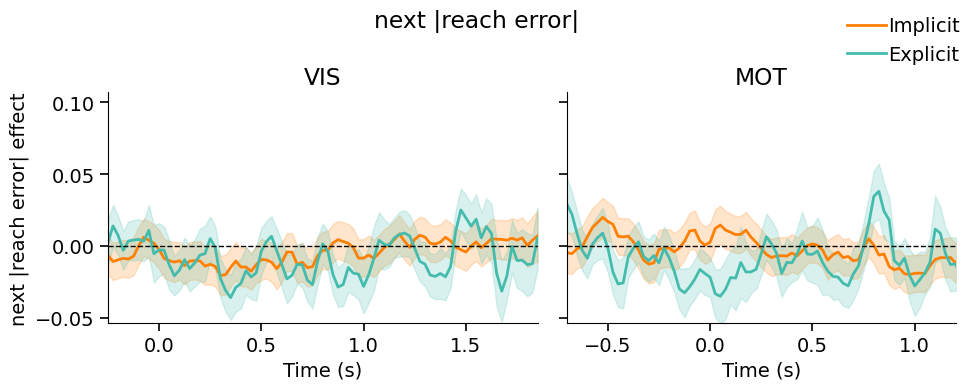

In [5]:
plot_var_results('reach_vis_abs_err_next_trial', 'next |reach error|')

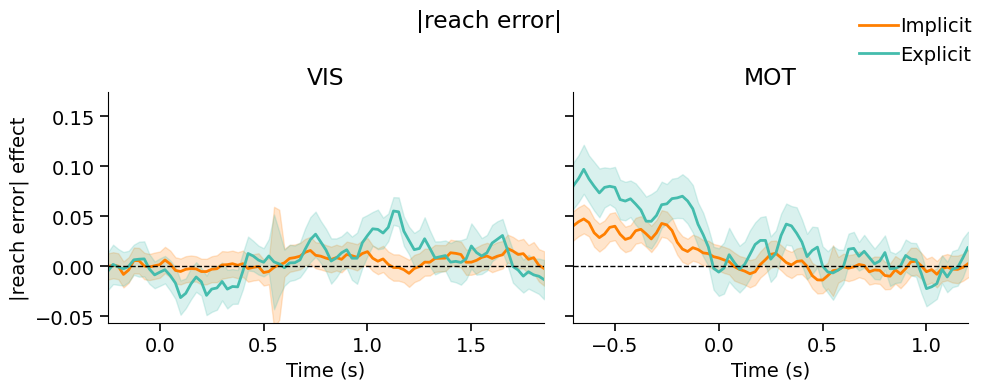

In [6]:
plot_var_results('reach_vis_abs_err', '|reach error|')

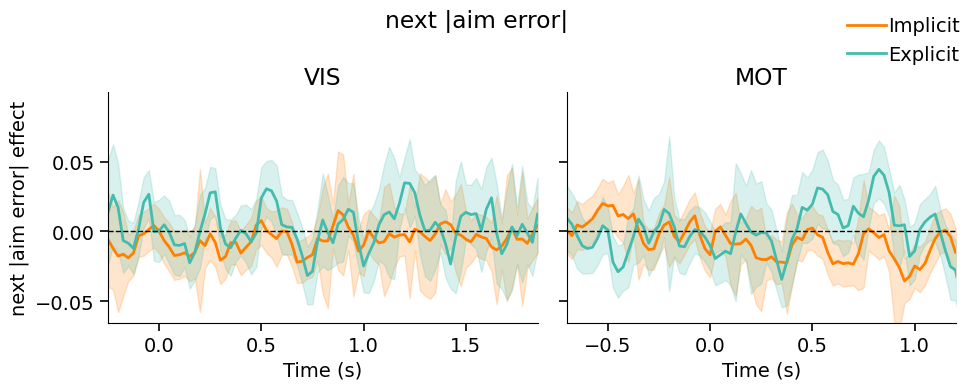

In [7]:
plot_var_results('aim_vis_abs_err_next_trial', 'next |aim error|')

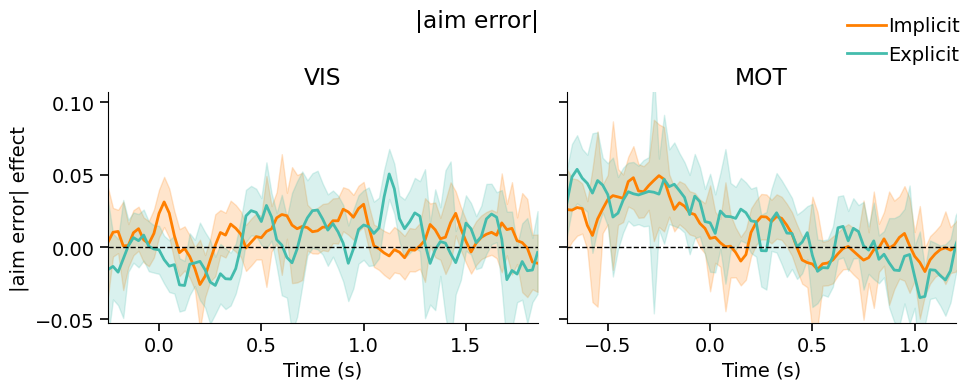

In [8]:
plot_var_results('aim_vis_abs_err', '|aim error|')

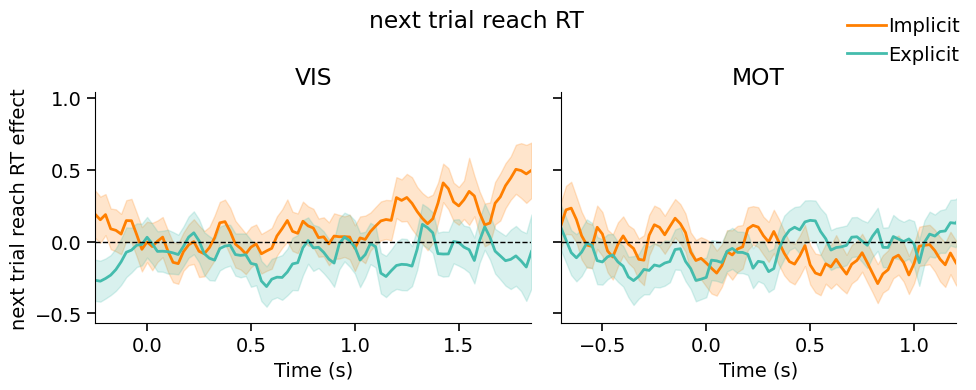

In [9]:
plot_var_results('reach_rt_next_trial', 'next trial reach RT')

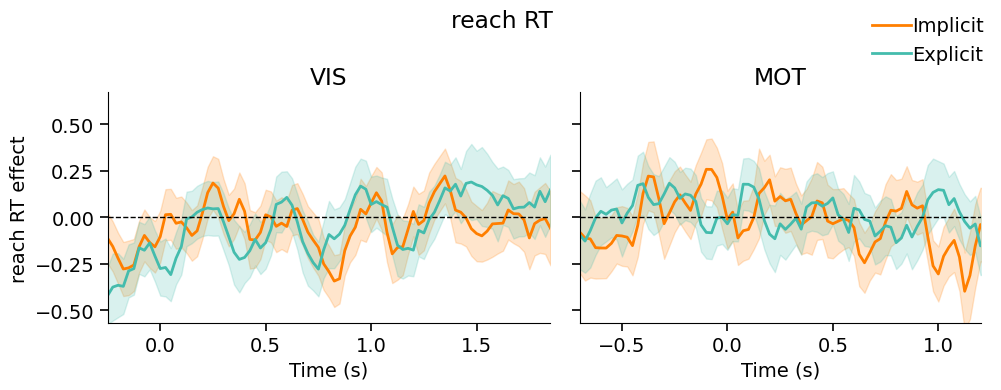

In [10]:
plot_var_results('reach_rt', 'reach RT')

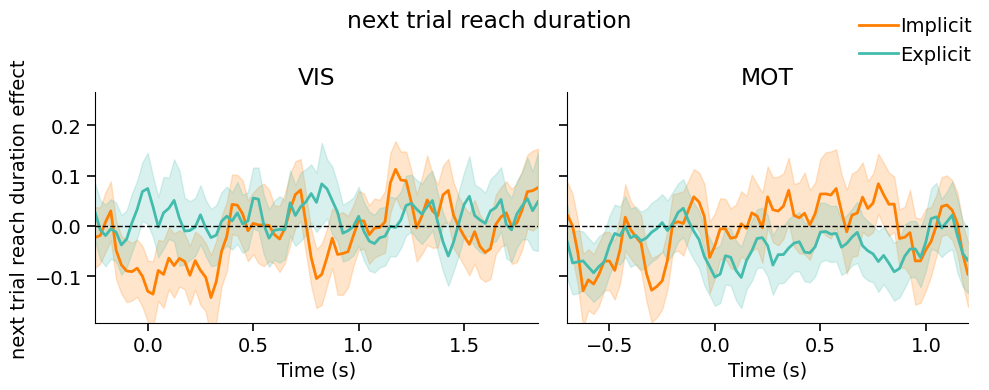

In [11]:
plot_var_results('reach_dur_next_trial', 'next trial reach duration')

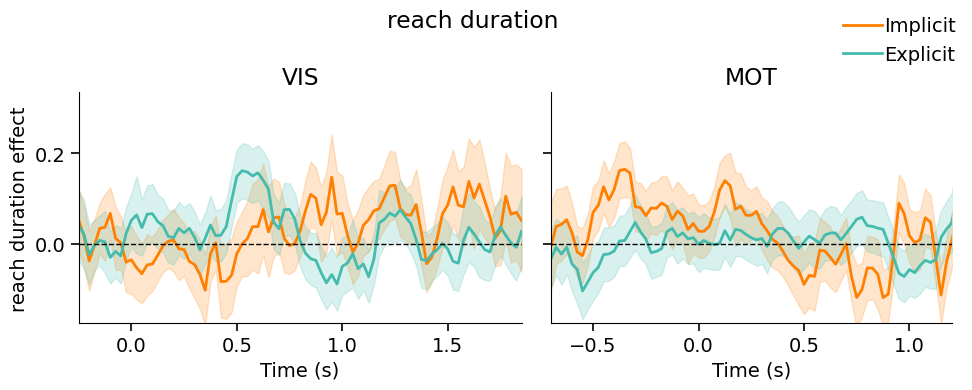

In [12]:
plot_var_results('reach_dur', 'reach duration')

In [13]:
def plot_all_vars(var_disp_list):
    group_colors = {"Implicit": colorbl[0], "Explicit": colorbl[1]}
    plot_lims = {'vis': vis_plot_lims, 'mot': mot_plot_lims}
    min_cluster_size = 15
    full_width_ratios = width_ratios * 2  # visual, motor × current, next

    current_vars = [(v, d) for v, d in var_disp_list if "next" not in v]
    next_vars = [(v, d) for v, d in var_disp_list if "next" in v]
    assert len(current_vars) == len(next_vars), "Mismatched number of current and next trial variables"

    fig, axes = plt.subplots(len(current_vars), 4, figsize=(16, 4 * len(current_vars)),
                             gridspec_kw={'width_ratios': full_width_ratios})
    if len(current_vars) == 1:
        axes = np.expand_dims(axes, 0)

    for row_idx, ((curr_var, curr_disp), (next_var, next_disp)) in enumerate(zip(current_vars, next_vars)):
        for col_block, (var_name, disp_name) in enumerate([(curr_var, curr_disp), (next_var, next_disp)]):
            vis_df = pd.read_csv(f"output/overall_vis_burst_rate_{var_name}.csv")
            mot_df = pd.read_csv(f"output/overall_mot_burst_rate_{var_name}.csv")
            try:
                vis_stats = pd.read_csv(f"output/overall_vis_{var_name}_win.csv")
            except:
                vis_stats = pd.DataFrame({
                    'pc': [],
                    'quartile': [],
                    'start': []
                })
            try:
                mot_stats = pd.read_csv(f"output/overall_mot_{var_name}_win.csv")
            except:
                mot_stats = pd.DataFrame({
                    'pc': [],
                    'quartile': [],
                    'start': []
                })

            if 'dur' in var_name or 'rt' in var_name:
                vis_df['estimate'] *= 1000
                mot_df['estimate'] *= 1000
                vis_df['SE'] *= 1000
                mot_df['SE'] *= 1000

            vis_df = vis_df[np.isfinite(vis_df["SE"])]
            mot_df = mot_df[np.isfinite(mot_df["SE"])]

            y_all = pd.concat([vis_df["estimate"], mot_df["estimate"]])
            y_min, y_max = y_all.min(), y_all.max()
            y_span = y_max - y_min
            y_offset_unit = 0.2 * y_span
            y_exp_marker = y_max + y_offset_unit
            y_imp_marker = y_exp_marker + y_offset_unit
            common_ylim = (y_min - y_offset_unit, y_imp_marker + y_offset_unit)

            for idx, (subset, limits, title, stats_df, full_df) in enumerate([
                (vis_df, plot_lims['vis'], "vis", vis_stats, vis_df),
                (mot_df, plot_lims['mot'], "mot", mot_stats, mot_df)
            ]):
                col_idx = col_block * 2 + idx
                ax = axes[row_idx, col_idx]

                stats_df=stats_df[(stats_df['start']>limits[0])]
        
                for group in group_colors:
                    df_group = subset[(subset['group'] == group) & (np.isfinite(subset['SE']))].copy()
                    if df_group.empty:
                        continue
                    time = df_group['time'].astype(float).values
                    est = df_group['estimate'].astype(float).values
                    se = df_group['SE'].astype(float).values
                    ax.plot(time, est, label=group, color=group_colors[group], linewidth=2)
                    ax.fill_between(time, est - se, est + se, alpha=0.2, color=group_colors[group])

                interaction_idxs=np.zeros(time.shape)

                for index, stats_row in stats_df.iterrows():
                    start=stats_row['start']
                    end=stats_row['end']
                    chi_sq=stats_row['chi_sq']
                    dof=stats_row['df']
                    p_val=stats_row['p_val']
                    if stats_row['factor']=='group:mean_burst_count':
                        exp_onesamp_z=stats_row['explicit_onesamp_z']
                        exp_onesamp_p=stats_row['explicit_onesamp_p']
                        imp_onesamp_z=stats_row['implicit_onesamp_z']
                        imp_onesamp_p=stats_row['implicit_onesamp_p']
                        explicit_implicit_z=stats_row['explicit_implicit_z']
                        explicit_implicit_p=stats_row['explicit_implicit_p']
                        
                        print(f'{title}: group:mean_burst_count {start}-{end}s, ChiSq({dof})={chi_sq}, p = {p_val}')
                        print(f'         explicit: z = {exp_onesamp_z}, p = {exp_onesamp_p}')
                        print(f'         implicit: z = {imp_onesamp_z}, p = {imp_onesamp_p}')
                        print(f'         explicit - implicit: z = {explicit_implicit_z}, p = {explicit_implicit_p}')
                        
                        t_idx=np.where((time>=start) & (time<end))[0]
                        if exp_onesamp_p<0.05:
                            ax.scatter(time[t_idx], [y_exp_marker] * len(t_idx),
                                       color=group_colors['Explicit'], marker="*", s=80, zorder=10)
                        if imp_onesamp_p<0.05:
                            ax.scatter(time[t_idx], [y_imp_marker] * len(t_idx),
                                       color=group_colors['Implicit'], marker="*", s=80, zorder=10)
                        interaction_idxs[t_idx]=True
                        
                for index, stats_row in stats_df.iterrows():
                    start=stats_row['start']
                    end=stats_row['end']
                    chi_sq=stats_row['chi_sq']
                    dof=stats_row['df']
                    p_val=stats_row['p_val']
                    if stats_row['factor']=='mean_burst_count':
                        print(f'{title}: mean_burst_count {start}-{end}s, ChiSq({dof})={chi_sq}, p = {p_val}')
                        t_idx=np.where((time>=start) & (time<end) & (interaction_idxs==0))[0]
                        ax.scatter(time[t_idx], [y_exp_marker] * len(t_idx),
                                   color=group_colors['Explicit'], marker="*", s=80, zorder=10)  
                        ax.scatter(time[t_idx], [y_imp_marker] * len(t_idx),
                                       color=group_colors['Implicit'], marker="*", s=80, zorder=10)

                ax.axhline(0, linestyle="--", color="black", linewidth=1)
                ax.set_ylim(*common_ylim)
                ax.set_xlim(limits)
                ax.set_title(f"{title.upper()}: {disp_name}")
                if idx == 0:
                    ax.set_ylabel("Effect size")
                else:
                    ax.set_yticklabels([])
                ax.set_xlabel("Time (s)")

    handles, labels = axes[0, 0].get_legend_handles_labels()
    axes[0, 0].legend(handles, labels, loc="upper left", frameon=False)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    # plt.savefig(os.path.join('./output/burst_behav_results', f'PC{pc}_Q{q}_allvars.pdf'))
    plt.show()



var_disp_list = [
    ('aim_vis_abs_err', '|aim error|'),
    ('aim_vis_abs_err_next_trial', 'next |aim error|'),
    ('reach_vis_abs_err', '|reach error|'),
    ('reach_vis_abs_err_next_trial', 'next |reach error|'),
    ('reach_rt', 'reach RT'),
    ('reach_rt_next_trial', 'next trial reach RT'),
    ('reach_dur', 'reach duration'),
    ('reach_dur_next_trial', 'next trial reach duration')
]


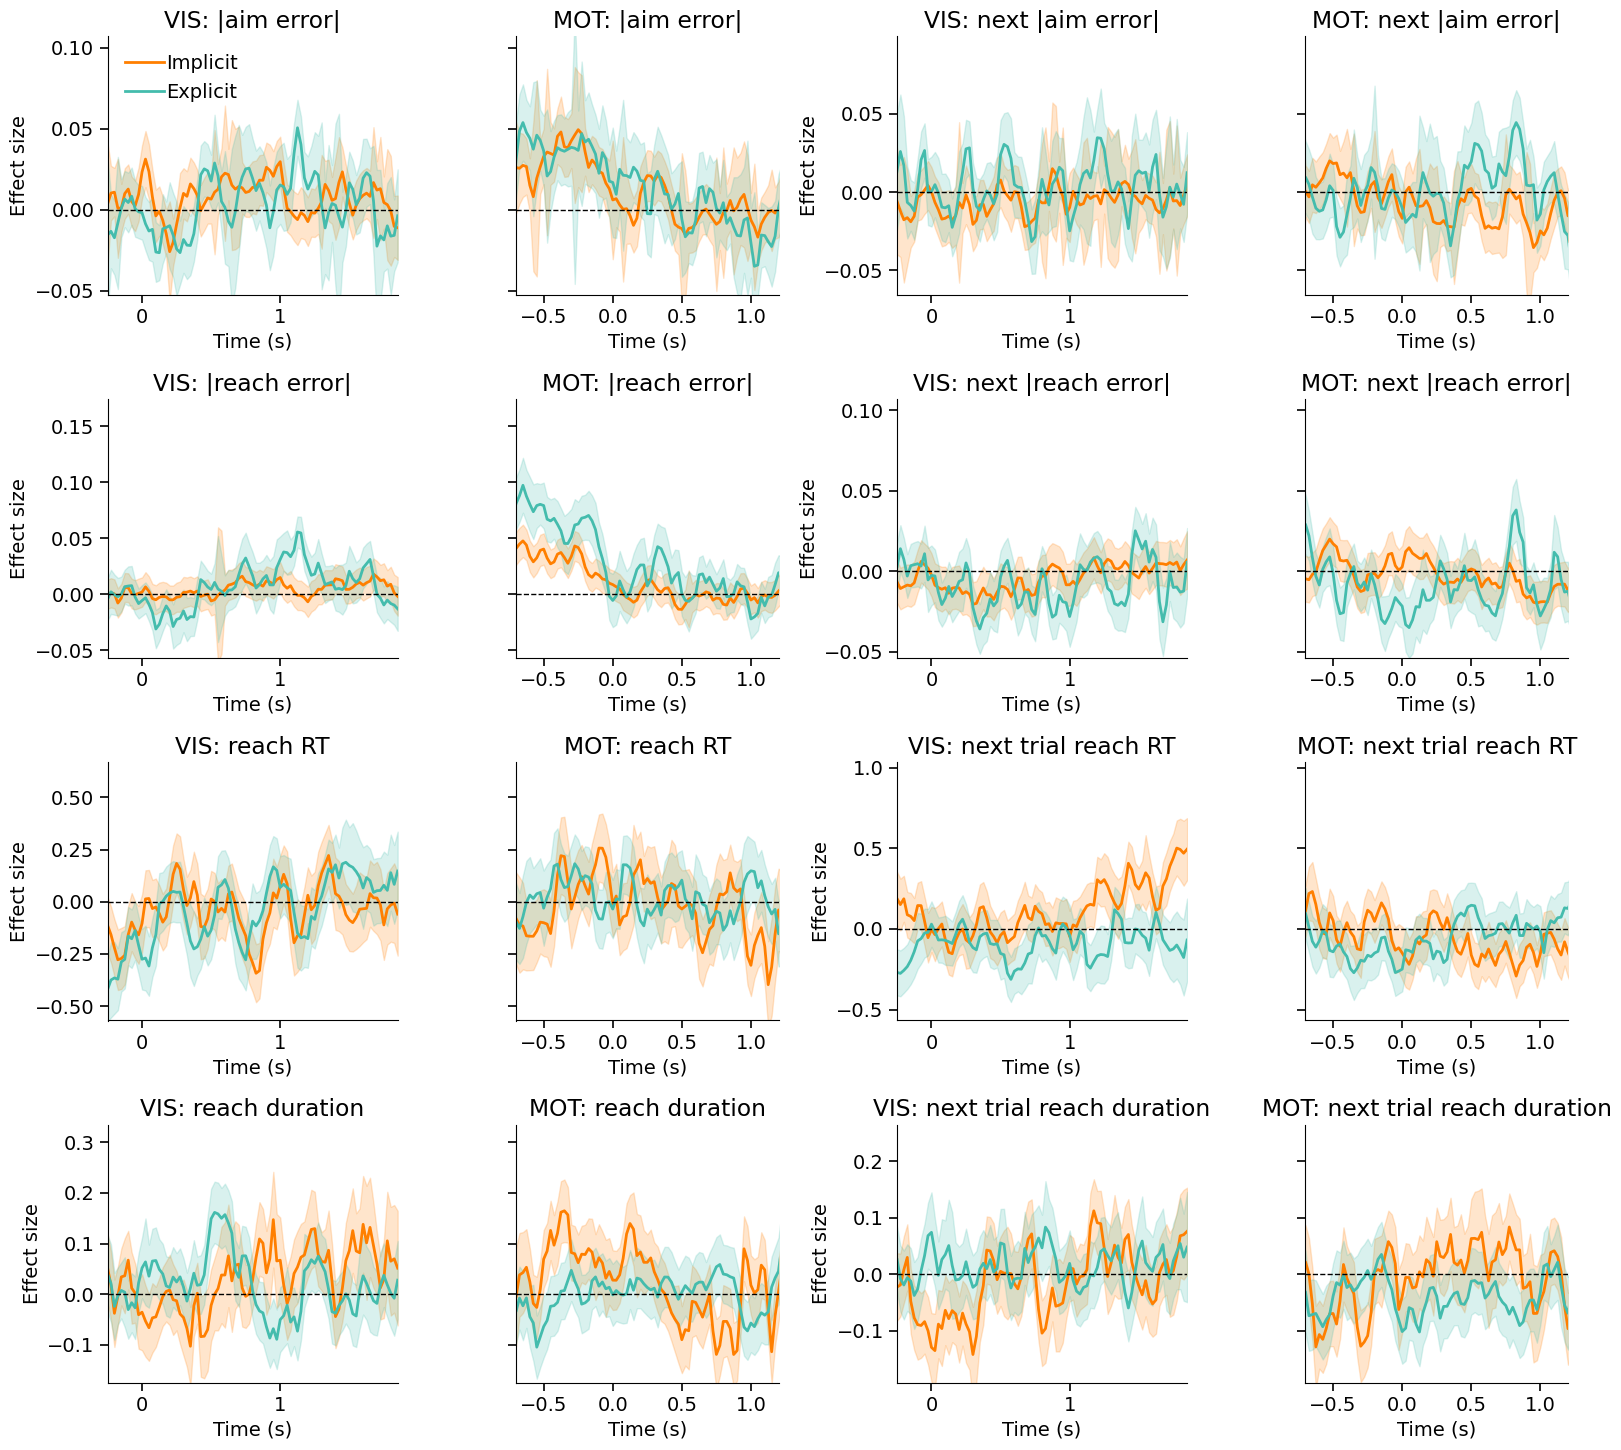

In [14]:
plot_all_vars(var_disp_list)